In [1]:
#Importing libraries
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import ast 

#Loading data
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset['train'].to_pandas()

#Data cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

d:\Anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


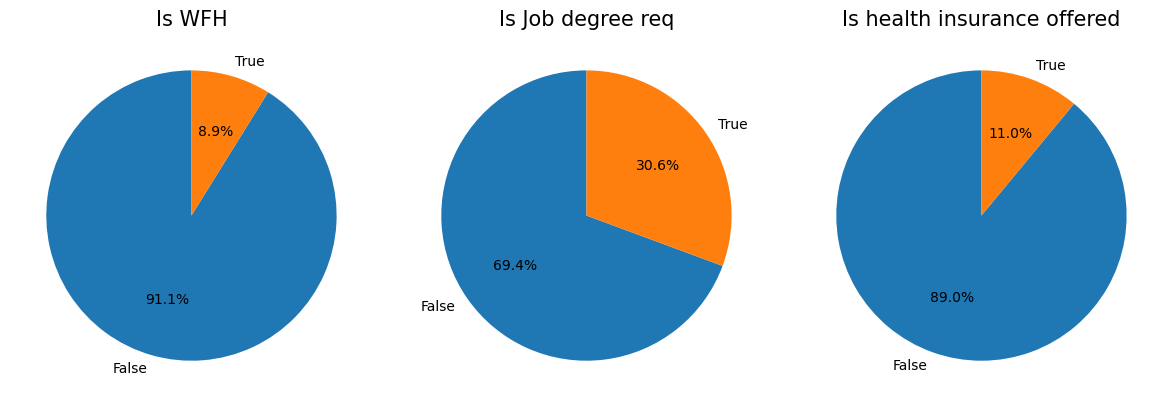

In [14]:
# Initialize a figure with 1 row and 3 columns for side-by-side comparison
fig, ax = plt.subplots(1, 3, figsize=(12, 4))

# Mapping dataframe columns to user-friendly titles for the plots
dict_column = {
    'job_work_from_home': 'Is WFH',
    'job_no_degree_mention': 'Is Job degree req',
    'job_health_insurance': 'Is health insurance offered'
}

# Iterate through the dictionary to populate each subplot
for i, (column, title) in enumerate(dict_column.items()):
    # Calculate frequency of each category and plot as a pie chart
    ax[i].pie(
        df[column].value_counts(), 
        startangle=90, 
        autopct='%1.1f%%',       # Display percentages with one decimal point
        labels=['False', 'True'] # Explicitly label the boolean categories
    )
    ax[i].set_title(title, fontsize=15)
# Adjust layout to prevent overlapping titles/labels and display the plot
fig.tight_layout()
plt.show()